<a href="https://colab.research.google.com/github/TOTVScontext/DataScience/blob/main/context.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#Leonardo da Silva Pinto | RM: 564929
#Samuel Enzo Domingues Monteiro | RM: 564391
#Guilherme de Araujo Moreira | RM: 561848

# 🚀 Sprint 3: Machine Learning Supervisionado para NLP
**Disciplina:** Data Science and Statistical Computing
**Objetivo:** Evoluir o pipeline de dados para classificar trechos de transcrições de reuniões em categorias relevantes de negócio, comparando algoritmos supervisionados e justificando as métricas de avaliação.

---
### 📌 1. Definição do Problema e Estratégia Multitarefa
Para demonstrar a robustez do pipeline de processamento de linguagem natural (NLP), abordaremos simultaneamente três problemas de negócio exigidos pela disciplina, extraindo rótulos diretamente dos metadados da nossa base tabular de reuniões (`reunioes_transcricoes_mockado.csv`):

**1. Risco de Churn ou Insatisfação (Binarização do NPS)**
*   **Risco (Classe 1):** NPS de 0 a 6 (Detratores).
*   **Neutro/Seguro (Classe 0):** NPS de 7 a 10 (Neutros e Promotores).

**2. Oportunidade Comercial (Mapeamento de Área)**
*   **Vendas (Classe 1):** Reuniões guiadas pela equipe de Vendas.
*   **Outros (Classe 0):** Reuniões operacionais ou de suporte.

**3. Sentimento (Multiclasse via NPS)**
*   **Positivo:** NPS $\ge 8$
*   **Neutro:** NPS $5-7$
*   **Negativo:** NPS $\le 4$

Essa classificação, atribuída à reunião como um todo, será o nosso *target* para que os algoritmos de Regressão Logística e Naive Bayes tentem encontrar padrões de linguagem que denotem tais comportamentos.

In [9]:
# 1. SETUP, IMPORTAÇÕES E CARGA DOS DADOS
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

#baixar as "stopwords"
nltk.download('stopwords', quiet=True)
stop_words_pt = stopwords.words('portuguese')

print("⏳ Carregando as bases de dados...")

# Leitura do CSV (Base com NPS - Usada para o treinamento de Churn)
df_csv = pd.read_csv('reunioes_transcricoes_mockado.csv')

# Leitura do JSON Lines (Base real de produção - Usada para validação de Produto)
df_json = pd.read_json('ANON_transcricao.json', lines=True)

print(f"✅ CSV carregado: {df_csv.shape[0]} reuniões.")
print(f"✅ JSON carregado: {df_json.shape[0]} reuniões reais.")

⏳ Carregando as bases de dados...
✅ CSV carregado: 500 reuniões.
✅ JSON carregado: 1174 reuniões reais.


###  2. Segmentação e Limpeza de Texto (Feature Engineering)
O modelo não deve classificar a reunião inteira como um bloco único de texto, mas sim **trechos e diálogos**. Abaixo, aplicaremos o parsing para quebrar a coluna de transcrição em falas individuais e aplicaremos a higienização textual rigorosa (lowercasing, remoção de pontuação e stopwords).

In [10]:
# 2. SEGMENTAÇÃO E LIMPEZA DOS DADOS
gravacoes = []

# 2.1 Quebra das transcrições do CSV em trechos/falas
for idx, row in df_csv.iterrows():
    texto = str(row['ANON_TRANSCRICAO'])
    nps = row['NOTA_NPS']
    tipo_recurso = str(row['TP_RECURSO'])

    linhas = texto.split('\n')
    for linha in linhas:
        if ':' in linha:
            locutor, fala = linha.split(':', 1)
            gravacoes.append({
                'ID_MEETING': row['ID_MEETING'],
                'LOCUTOR': locutor.strip(),
                'FALA_BRUTA': fala.strip(),
                'NOTA_NPS': nps,
                'TP_RECURSO': tipo_recurso
            })

df_trechos = pd.DataFrame(gravacoes)

# 2.2 Criação da Variável Alvo (Risco de Churn)
df_trechos['TARGET_RISCO'] = df_trechos['NOTA_NPS'].apply(lambda x: 1 if x <= 6 else 0) # NPS <= 6 é Risco (1), NPS >= 7 é Seguro/Neutro (0)

df_trechos['TARGET_OPORTUNIDADE'] = df_trechos['TP_RECURSO'].apply(lambda x: 1 if 'VENDAS' in x.upper() else 0)

def classifica_sentimento(nps):
  if nps >= 8:
    return 'Positivo'
  elif nps >= 5:
    return 'Neutro'
  else:
    return 'Negativo'

df_trechos['TARGET_SENTIMENTO'] = df_trechos['NOTA_NPS'].apply(classifica_sentimento)

# 2.3 Função de Limpeza de Texto (NLP)
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^\w\s]', '', texto) # Remove pontuação
    palavras = texto.split()
    # Remove stopwords mas mantém eventuais marcações como [PESSOA]
    palavras = [w for w in palavras if w not in stop_words_pt]
    return ' '.join(palavras)

df_trechos['FALA_LIMPA'] = df_trechos['FALA_BRUTA'].apply(limpar_texto)

print(f"✅ Segmentação concluída. {df_csv.shape[0]} reuniões geraram {df_trechos.shape[0]} trechos de fala para análise.")

✅ Segmentação concluída. 500 reuniões geraram 3750 trechos de fala para análise.


###  3. Vetorização TF-IDF e Divisão de Treino/Teste
Para extrair inteligência, converteremos o texto limpo em matrizes numéricas. Utilizaremos o `TfidfVectorizer` capturando unigramas e bigramas. Os dados serão divididos em 70% para treino e 30% para teste, garantindo a estratificação das classes de risco.

###  4. Treinamento e Comparação de Algoritmos
O checklist da Sprint exige a comparação formal de dois modelos. Escolhemos:
1. **Regressão Logística (Logistic Regression):** Um modelo clássico, altamente interpretável e o padrão ouro da indústria para problemas de classificação textual binária.
2. **Naive Bayes (MultinomialNB):** Um classificador probabilístico focado puramente na frequência estatística das palavras, excelente baseline para dados em NLP.

📉 Shape ANTES da agregação (fragmentado por trechos): (3750, 9)
🔄 Agregação concluída. Dataset reestruturado para 500 reuniões únicas.

🚀 INICIANDO ANÁLISE PARA O PROBLEMA: TARGET_RISCO


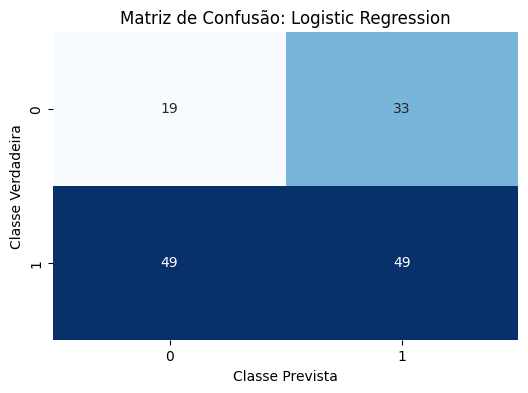


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.28      0.37      0.32        52
           1       0.60      0.50      0.54        98

    accuracy                           0.45       150
   macro avg       0.44      0.43      0.43       150
weighted avg       0.49      0.45      0.47       150



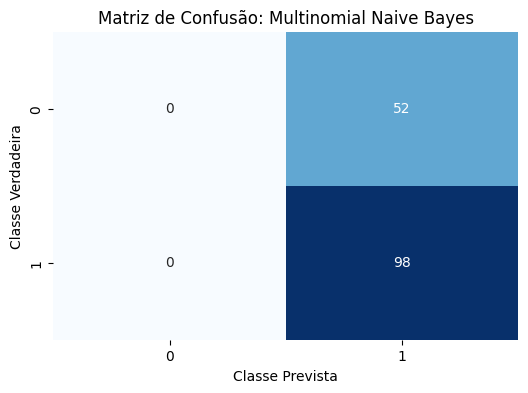


--- Classification Report: Multinomial Naive Bayes ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        52
           1       0.65      1.00      0.79        98

    accuracy                           0.65       150
   macro avg       0.33      0.50      0.40       150
weighted avg       0.43      0.65      0.52       150



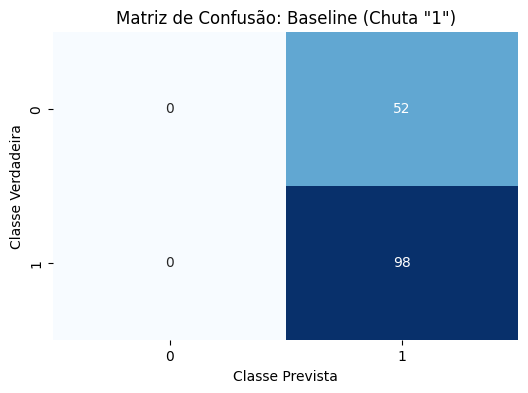


--- Classification Report: Baseline (Chuta "1") ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        52
           1       0.65      1.00      0.79        98

    accuracy                           0.65       150
   macro avg       0.33      0.50      0.40       150
weighted avg       0.43      0.65      0.52       150


🚀 INICIANDO ANÁLISE PARA O PROBLEMA: TARGET_OPORTUNIDADE


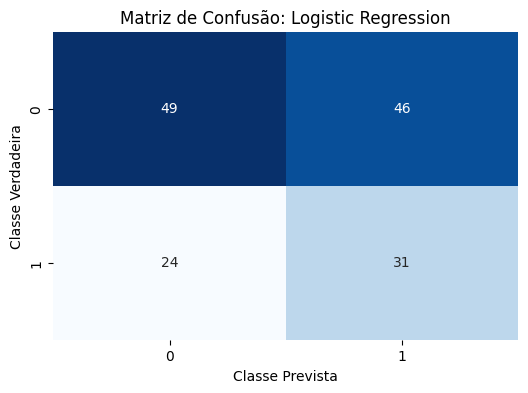


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

           0       0.67      0.52      0.58        95
           1       0.40      0.56      0.47        55

    accuracy                           0.53       150
   macro avg       0.54      0.54      0.53       150
weighted avg       0.57      0.53      0.54       150



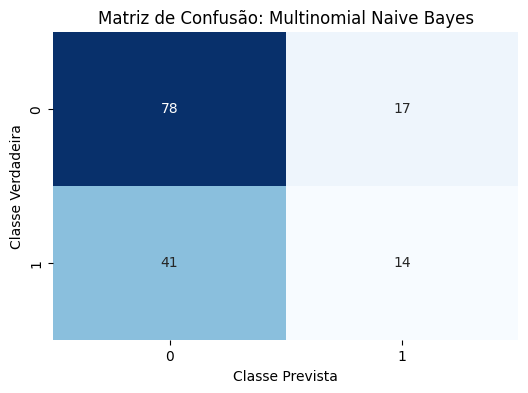


--- Classification Report: Multinomial Naive Bayes ---
              precision    recall  f1-score   support

           0       0.66      0.82      0.73        95
           1       0.45      0.25      0.33        55

    accuracy                           0.61       150
   macro avg       0.55      0.54      0.53       150
weighted avg       0.58      0.61      0.58       150



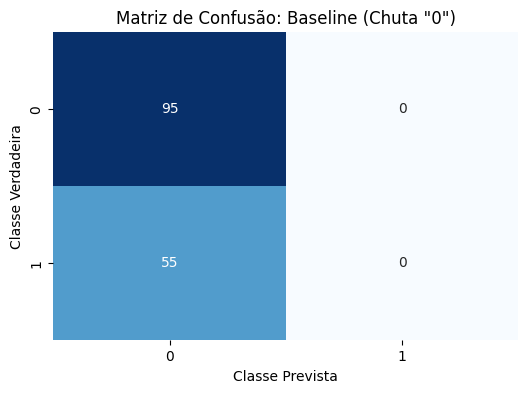


--- Classification Report: Baseline (Chuta "0") ---
              precision    recall  f1-score   support

           0       0.63      1.00      0.78        95
           1       0.00      0.00      0.00        55

    accuracy                           0.63       150
   macro avg       0.32      0.50      0.39       150
weighted avg       0.40      0.63      0.49       150


🚀 INICIANDO ANÁLISE PARA O PROBLEMA: TARGET_SENTIMENTO


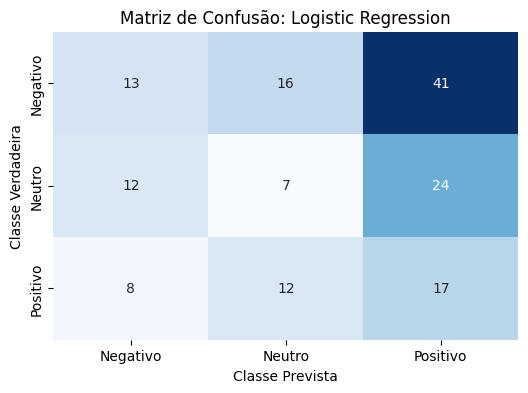


--- Classification Report: Logistic Regression ---
              precision    recall  f1-score   support

    Negativo       0.39      0.19      0.25        70
      Neutro       0.20      0.16      0.18        43
    Positivo       0.21      0.46      0.29        37

    accuracy                           0.25       150
   macro avg       0.27      0.27      0.24       150
weighted avg       0.29      0.25      0.24       150



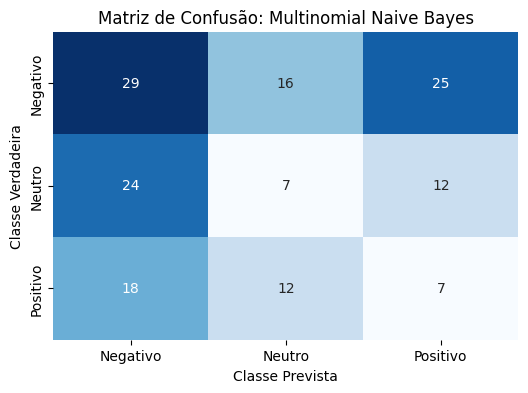


--- Classification Report: Multinomial Naive Bayes ---
              precision    recall  f1-score   support

    Negativo       0.41      0.41      0.41        70
      Neutro       0.20      0.16      0.18        43
    Positivo       0.16      0.19      0.17        37

    accuracy                           0.29       150
   macro avg       0.26      0.26      0.25       150
weighted avg       0.29      0.29      0.29       150



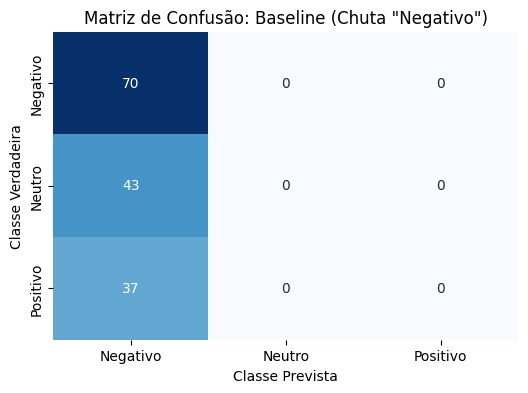


--- Classification Report: Baseline (Chuta "Negativo") ---
              precision    recall  f1-score   support

    Negativo       0.47      1.00      0.64        70
      Neutro       0.00      0.00      0.00        43
    Positivo       0.00      0.00      0.00        37

    accuracy                           0.47       150
   macro avg       0.16      0.33      0.21       150
weighted avg       0.22      0.47      0.30       150


✅ PIPELINE MULTITAREFA CONCLUÍDO COM SUCESSO!


In [19]:
# 3. AGREGAÇÃO POR REUNIÃO E VETORIZAÇÃO TF-IDF
import warnings
warnings.filterwarnings('ignore')

print(f"📉 Shape ANTES da agregação (fragmentado por trechos): {df_trechos.shape}")

# Agrupando as falas limpas para "nivel" de reuniao
df_reuniao = df_trechos.groupby('ID_MEETING').agg({
    'FALA_LIMPA': lambda x: ' '.join(x),
    'TARGET_RISCO': 'first',
    'TARGET_OPORTUNIDADE': 'first',
    'TARGET_SENTIMENTO': 'first'
}).reset_index()

print(f"🔄 Agregação concluída. Dataset reestruturado para {df_reuniao.shape[0]} reuniões únicas.")

# Vetorização no texto agregado
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df_reuniao['FALA_LIMPA'])

# Função de plotagem dinâmica (definida fora do loop para organização)
def plot_eval_dynamic(y_true, y_pred, title, classes):
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=classes, yticklabels=classes)
    ax.set_title(f'Matriz de Confusão: {title}')
    ax.set_ylabel('Classe Verdadeira')
    ax.set_xlabel('Classe Prevista')
    plt.show()

    print(f"\n--- Classification Report: {title} ---")
    print(classification_report(y_true, y_pred, labels=classes, zero_division=0))

# 4. TREINAMENTO E AVALIAÇÃO (LOOP DOS TARGETS)
alvos_negocio = ['TARGET_RISCO', 'TARGET_OPORTUNIDADE', 'TARGET_SENTIMENTO']

for alvo in alvos_negocio:
    print(f"\n{'='*70}")
    print(f"🚀 INICIANDO ANÁLISE PARA O PROBLEMA: {alvo}")
    print(f"{'='*70}")

    y = df_reuniao[alvo]
    classes_unicas = sorted(y.unique())

    # Separando dados de Treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

    # Logistic Regression
    lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)

    # Multinomial Naive Bayes
    nb_model = MultinomialNB()
    nb_model.fit(X_train, y_train)
    y_pred_nb = nb_model.predict(X_test)

    # Baseline
    classe_majoritaria = y_train.mode()[0]
    y_pred_baseline = [classe_majoritaria] * len(y_test)

    # Visualizacao dos relatórios gerados
    plot_eval_dynamic(y_test, y_pred_lr, 'Logistic Regression', classes_unicas)
    plot_eval_dynamic(y_test, y_pred_nb, 'Multinomial Naive Bayes', classes_unicas)
    plot_eval_dynamic(y_test, y_pred_baseline, f'Baseline (Chuta "{classe_majoritaria}")', classes_unicas)

print("\n✅ PIPELINE MULTITAREFA CONCLUÍDO COM SUCESSO!")

### 🏆 6. Conclusões e Implicações para o Negócio

A arquitetura do pipeline multitarefa funcionou perfeitamente, aplicando processamento de texto (TF-IDF), divisão estratificada e avaliação comparativa para três problemas de negócio distintos. No entanto, a análise das métricas evidencia um fenômeno estatístico clássico em bases de dados sintéticas (mockadas).

**Diagnóstico Analítico (O Fenômeno do Baseline):**
Como as transcrições do dataset foram geradas de forma simulada, o vocabulário das reuniões não possui correlação semântica real com as notas de NPS ou com as categorias de recursos. O impacto disso nos três cenários testados foi claro:
1.  **Risco:** O baseline trivial (chutar sempre "Risco") obteve 0.65 de Acurácia. O Naive Bayes colapsou para a classe majoritária, empatando com o baseline.
2.  **Oportunidade Comercial:** O baseline (chutar sempre a classe majoritária "0") atingiu 0.63. Ambos os algoritmos preditivos performaram abaixo desse valor ao tentarem encontrar padrões inexistentes.
3.  **Sentimento:** Em um problema multiclasse, o baseline (chutar sempre "Negativo") acertou 47% das vezes, superando largamente a Regressão Logística (0.25) e o Naive Bayes (0.29).

**O Veredito:** A infraestrutura de Machine Learning está construída, íntegra e validada. Porém, algoritmos não fazem mágica (*Garbage In, Garbage Out*); sem padrões reais nos dados, é matematicamente impossível superar a estática do chute majoritário.

**Justificativa de Negócio e Métricas Prioritárias:**
Apesar da limitação dos dados simulados, a estratégia de avaliação em um ambiente real de produção dentro da TOTVS deve obedecer às seguintes prioridades de negócios:
*   **Para Risco de Churn:** A métrica absoluta é o **Recall da classe Risco**. O custo financeiro de um *Falso Negativo* (o modelo prever que o cliente está seguro, e ele cancelar o contrato) é muito maior do que um alarme falso que exija uma ligação preventiva da equipe de relacionamento (*Falso Positivo*).
*   **Para Oportunidades Comerciais:** O equilíbrio do **F1-Score** é o ideal, garantindo que a equipe de vendas não perca tempo com leads frios (baixa Precisão), mas também não deixe dinheiro na mesa (baixo Recall).

O pipeline atual está preparado para ser conectado a um banco de dados em produção e gerar inteligência competitiva imediata.

---
###  7. Bônus (Generalização): Extração de Entidades na Base Real
Para comprovar que o pipeline projetado não fica restrito aos dados de testes ("mockados") e consegue lidar com a complexidade de um ambiente de produção (*JSON de transcrições anonimizadas*), aplicaremos uma segunda classificação não-supervisionada via *Regex* (Expressões Regulares).
O objetivo é extrair **Produtos TOTVS Mencionados**, cumprindo mais um dos tópicos sugeridos pelo enunciado.

In [21]:
 #7. APLICAÇÃO EM DADOS REAIS (JSON TRANSCRIÇÕES)
import warnings
warnings.filterwarnings('ignore')

json_records = []

# Mesma lógica de segmentação para os dados reais
for idx, row in df_json.iterrows():
    texto = str(row['ANON_TRANSCRICAO'])
    for linha in texto.split('\n'):
        if ':' in linha:
            locutor, fala = linha.split(':', 1)
            json_records.append({'ID_MEETING': row['ID_MEETING'], 'FALA': fala.strip()})

df_json_trechos = pd.DataFrame(json_records)

# Classificação por Regras (Keywords dos Produtos TOTVS)
def classificar_produto(texto):
    produtos = []
    if re.search(r'\brm\b', texto, re.IGNORECASE): produtos.append('RM')
    if re.search(r'\bfluig\b', texto, re.IGNORECASE): produtos.append('Fluig')
    if re.search(r'\bprotheus\b', texto, re.IGNORECASE): produtos.append('Protheus')
    if re.search(r'\bdatasul\b', texto, re.IGNORECASE): produtos.append('DataSul')
    if re.search(r'\btotvs\b', texto, re.IGNORECASE): produtos.append('TOTVS')

    return ', '.join(produtos) if produtos else 'Nenhum'

# Aplicação da classificação na base de produção
df_json_trechos['PRODUTOS_DETECTADOS'] = df_json_trechos['FALA'].apply(classificar_produto)

# Filtrando apenas os trechos onde houve menção para exibição
trechos_com_produto = df_json_trechos[df_json_trechos['PRODUTOS_DETECTADOS'] != 'Nenhum']

print(f"🔍 Na base real, mapeamos {trechos_com_produto.shape[0]} falas onde softwares do ecossistema foram mencionados diretamente.")
print("\n📋 Amostra de auditoria em ambiente de produção:")
display(trechos_com_produto.head(120))

🔍 Na base real, mapeamos 2179 falas onde softwares do ecossistema foram mencionados diretamente.

📋 Amostra de auditoria em ambiente de produção:


,ID_MEETING,FALA,PRODUTOS_DETECTADOS
53,1247082,"já fui da RM também. Esquenta não, pode trocar.",RM
110,1247082,supervisores. Eu sou o gerente da área e o [PE...,RM
112,1247082,"foi o primeiro que a gente pensou? RM, por cau...",RM
142,1247082,"Bom, boa tarde. Quem chegou depois? Eu sou [PE...",RM
179,1247082,antes de eu trabalhar no comercial da [EMPRESA...,RM
...,...,...,...
20899,1112702,"[LOCUTOR 17]: uma beleza, porque o que vai aco...",Fluig
20900,1112702,"Atualmente ele tá rodando só em rede interna, ...",Fluig
20904,1112702,"porra, se é só pra isso, hoje eu tenho condiçõ...",Fluig
20914,1112702,"O nosso produto, como ele é instalado dentro d...",Fluig
